#**Actividad 2**

###**Maestría en Inteligencia Artificial Aplicada**
###**Curso: Inteligencia Artificial y Aprendizaje Automático**
####**Tecnológico de Monterrey**
#####**Prof Luis Eduardo Falcón Morales**

###**Nombre del estudiante: Sergio Alberto Chavez Velazquez

###**Matrícula: A01099484

**NOTAS:**

*   Esta actividad la puedes realizar en Google-Colab.
*   Usaremos un conjunto de datos bastante conocido, llamado California_Housing o California_Housing_Prices. El objetivo en este caso es predecir el costo mediano de una casa en el estado de California, a partir de la información que se proporciona de la misma.
* Esta base de datos es muy conocida y a lo largo de los años ha sufrido muchas modificaciones, pero todas ellas siguen siendo utilizadas para su análisis.
*   En particular, en esta actividad usaremos los datos del archivo llamado california_housing_train.csv que se encuentra en la carpeta **sample_data**, en la sección de **Archivos** del Google-Colab que se encuentra en el menú ubicado a la izquierda.
* La información sobre el significado de las variables la puedes encontrar en la siguiente liga de Kaggle. Sin embargo, cabe mencionar que estrictamente los datos son diferentes a los del Google-Colab, por lo que solamente utiliza esta liga para obtener el significado de las variables: https://www.kaggle.com/datasets/camnugent/california-housing-prices

* Mencionamos también que el archivo california_housing_train.csv ya representa al conjunto de entrenamiento, por lo que no hace falta hacer una partición adicional para los análisis que estaremos haciendo.
*   Por otro lado, no es necesario trabajar con Google-Colab, puedes cargar y trabajar los datos en el entorno de desarrollo integrado (IDE) de tu preferencia.
* En esta actividad el código en Python ya está dado y no es necesario agregar más código. Sin embargo, si deseas incluir algún código adicional para justificar alguna de tus respuestas, lo puedes hacer, pero debes agregarlo en una nueva celda de código y no modificar en absoluto el código que ya está dado.
* Para responder a las preguntas de esta actividad, puedes apoyarte en alguna bibliografía del tema, o bien, mediante el uso de alguno de los llamados Modelos de Gran Tamaño, LLM, por sus siglas en inglés Large Language Model.
* Cuando utilices uno o varios LLM para responder una pregunta, deberás indicar cuál fue o fueron los utilizados. Por ejemplo, chatGPT, Copilot, Gemini, Claude, etc. De hecho, durante el presente curso nos estaremos apoyando constantemente en los modelos LLM.



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import power_transform


In [ ]:
# Si estás ejecutando este cuaderno de Jupyter desde Google Colab, podemos
# cargar el archivo desde la siguiente carpeta:
DIR = "/content/sample_data/"
os.chdir(DIR)

# Una vez cargado los datos de entrenamiento, obtenemos una descripción de cada variable:
misdatos = pd.read_csv("california_housing_train.csv", sep=",")
print("Dimensión del conjunto de entrenamiento:", misdatos.shape)
misdatos.describe()

Dimensión del conjunto de entrenamiento: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# **Ejercicio 1 : Transformación de Variables**

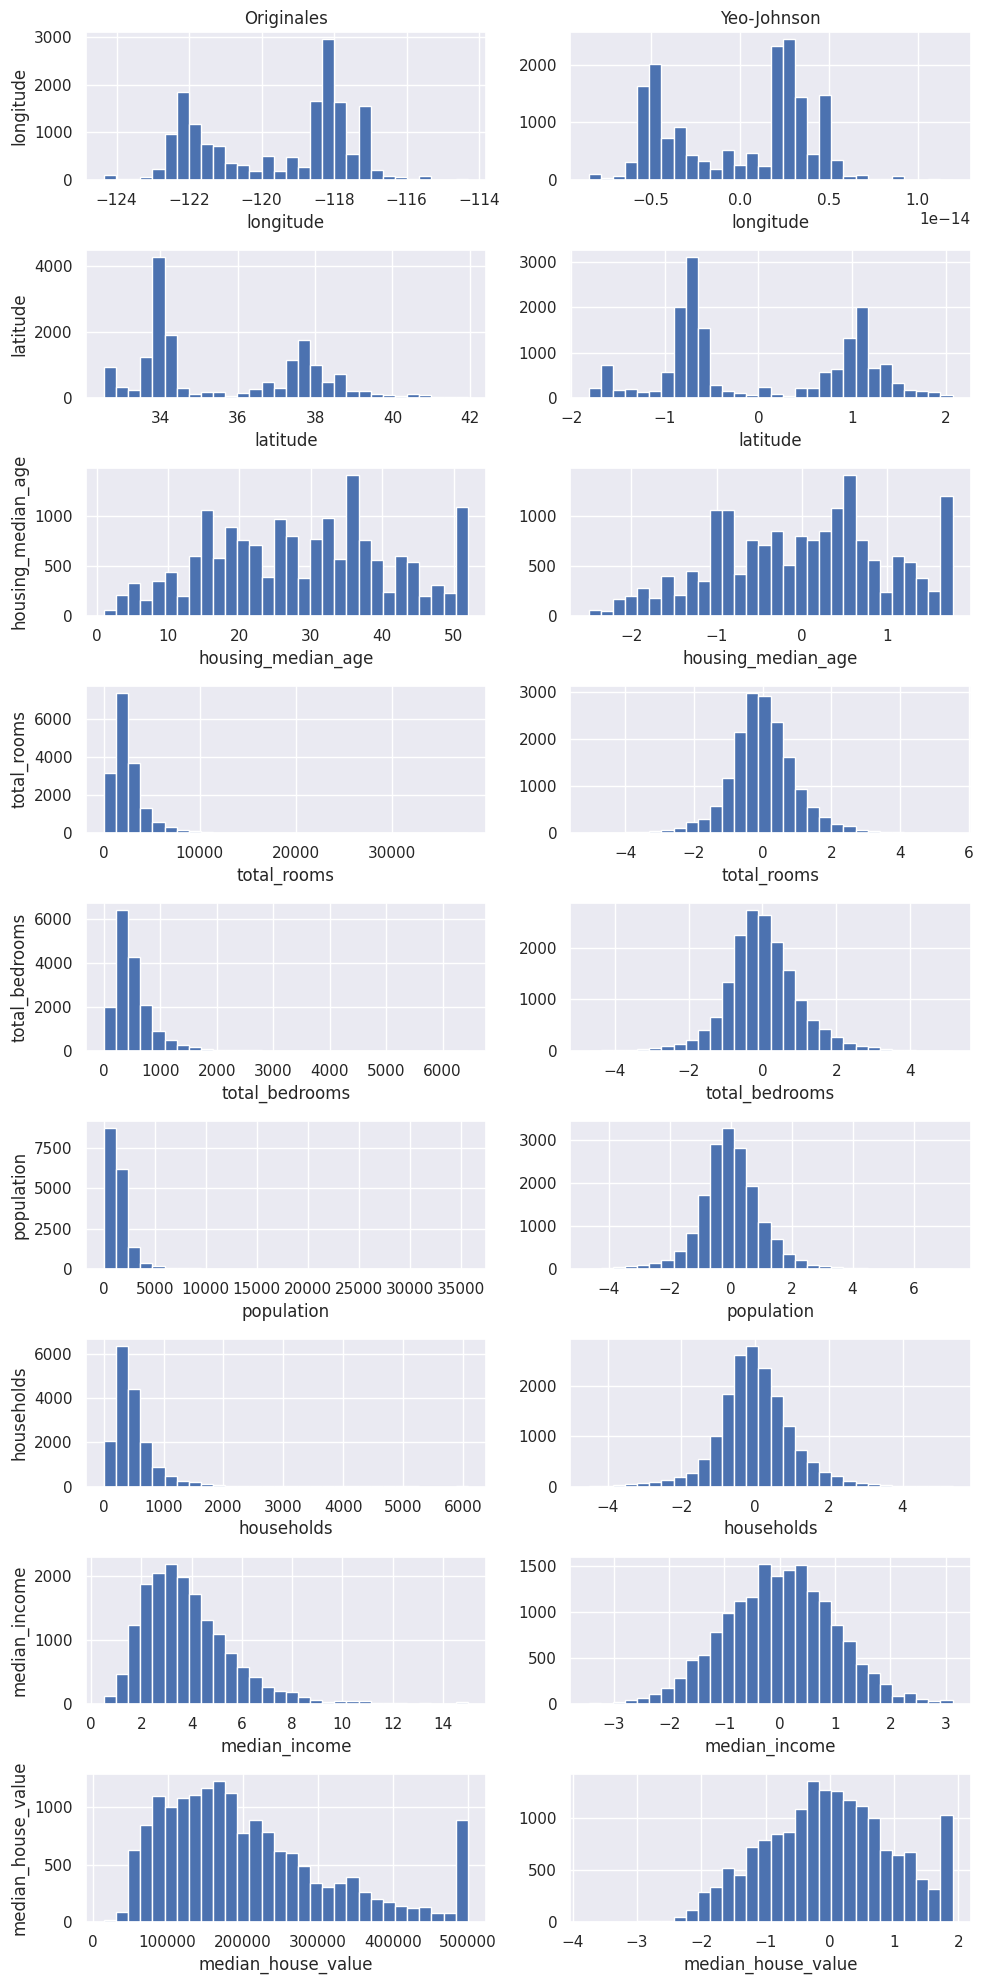

In [ ]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Obtengamos los siguientes histogramas de los datos originales y sus transformaciones indicadas:

# Lista de las variables a transformar:
variables_a_transformar = ['longitude','latitude','housing_median_age','total_rooms',
                           'total_bedrooms','population','households','median_income',
                           'median_house_value']

yj = []  # para guardar las transformaciones obtenidas y usarlas más adelante con Pearson.

# Configuramos el entorno gráfico y mostramos los histogramas originales y los transformados:
sns.set(rc={'figure.figsize':(10,20)})
fig, axes = plt.subplots(len(variables_a_transformar),2)

for k in range(0, len(variables_a_transformar)):

    # Datos originales:
    Transf_originales = misdatos[variables_a_transformar[k]]

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 1)
    plt.hist(Transf_originales, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Originales')
    plt.ylabel(variables_a_transformar[k]) # Esta es la etiqueta de cada variable.


    # Datos transformados con Yeo-Johnson:
    # La transformación .to_numpy().reshape(-1,1) es porque power_transform espera una entrada 2D
    Transf_yeojohnson = power_transform((Transf_originales.to_numpy()).reshape(-1,1), method ='yeo-johnson')
    yj.append(Transf_yeojohnson)

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 2)
    plt.hist(Transf_yeojohnson, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Yeo-Johnson')

plt.tight_layout()
plt.show()

**Observa que las variables de entrada total_rooms, total_bedrooms, population y households, están claramente sesgadas positivamente. Y la variable de entrada median_income y la de salida median_house_value, un poco menos sesgadas.**



**PREGUNTAS:**

En los siguientes ejercicios supongamos que estamos analizando y preparando los datos para aplicar posteriormente un modelo de regresión lineal múltiple.

*   **Pregunta 1.1.** ¿Para qué se aplica usualmente la transformación Yeo-Johnson y cuál es su diferencia con Box-Cox?

*   **Pregunta 1.2.** ¿Cuál es la diferencia entre utilizar la métrica de la raíz cuadrada del error cuadrático medio RMSE (Root Mean Squared Error) y la del error absoluto medio MAE (Mean Absolute Error)? ¿Cuándo se recomienda utilizar cada uno?

*   **Pregunta 1.3.** Si vamos a aplicar posteriormente el modelo de regresión lineal múltiple y habiendo observado de los histogramas que las variables de entrada total_rooms, total_bedrooms, population, households y median_income tienen sesgos positivos ¿es recomendable aplicar alguna transformación de corrección de sesgo, como la mostrada de Yeo-Johnson en dichas variables? ¿Por qué?

*   **Pregunta 1.4.** Considerando ahora todas las variables de entrada de este problema, ¿es recomendable aplicarles alguna transformación de ajuste de escala (por ejemplo, la min-max, o la de normalización) antes de aplicar el modelo de regresión lineal múltiple? ¿Por qué?

*   **Pregunta 1.5.** Supongamos que ya decidiste aplicar la transformación Yeo-Johnson a las varibles sesgadas identificadas previamente. Una vez aplicada la Yeo-Johnson, ¿también es válido o recomendable aplicarles ahora una transformación de escala? ¿Por qué? En particular observa los histogramas resultantes con Yeo-Johnson obtenidos anteriormente para respaldar tu respuesta.

*   **Pregunta 1.6.** Supongamos que por alguna razón ya decidiste aplicar a las variables sesgadas tanto la transformación Yeo-Johnson, como la transformación de escala, ¿sería lo mismo aplicar primero la Yeo-Johnson seguida de la transformación de escala, que si lo hiciéramos al revés, es decir, primero la transformación de escala y luego la Yeo-Johnson? Justifica tu respuesta.

*   **Pregunta 1.7.** Observa ahora los histogramas de las variables de entrada originales "longitude" y "latitude". Claramente podríamos considerar a dichos histogramas como gráficos bimodales. ¿Qué se recomienda hacer en este caso? Es decir, ¿qué tipo de transformación o transformaciones se recomiendan aplicar? En particular, en este caso se observa que para estas variables la Yeo-Johnson no ayudó en absoluto.


*   **Pregunta 1.8.** Analicemos ahora la variable de salida median_house_value. ¿Cuál es ahora la recomendación para ajustar o transformar el sesgo o de corrección de escala? ¿Serían exactamente las mismas recomendaciones que se hicieron para las variables de entrada o se aplicaría un criterio diferente? Justifica tu respuesta.

*   **Pregunta 1.9.** Observa ahora el histograma de la variable de salida "median_house_value", ya sea la original o la transformada. Claramente se observa un "pico" al final de cualquiera de estos histogramas. ¿Qué transformación, criterio o recomendación adicional aplicaría para este tipo de gráficos?

### **Respuestas:**


++++++++ Inicia sección para agregar texto ++++++++++++++++++++++++++


*   **Respuesta 1.1.** La transformación de Yeo-Johnson se aplica principalmente en estadística y machine learning para transformar una variable continua de modo que su distribución se aproxime a una distribución normal y para estabilizar la varianza de los datos, asi los numeros pequeños no se hacen invisibles con los nuumeros grandes. La Principal diferencia con el Metodo Box-Cox es que en Yeo Johnson puede usar cualquier tipo de numeros mientras que con Box Cox no se pueden usar ceros ni numeros negartivos.

*   **Respuesta 1.2.** Ambas métricas miden el error promedio de predicción en un modelo de regresión en las mismas unidades que la variable objetivo, pero ponderan las desviaciones de forma completamente distinta.
La diferencia principal entre Raíz Cuadrada del Error Cuadrático Medio (RMSE) y el Error Absoluto Medio (MAE)  radica en cómo se consideran las deviaciones
La métrica MAE es Recomendable cuando los errores grandes no traen una afectación tan grande en el modelo  y no tienen un impacto catastrófico. También es útil cuando no quieres que pocos datos con errores grandes dominen tu modelo. Otro caso útil es cuando intentas simplificar el resultado a áreas no técnicas.
Por otra parte la métrica cuando los errores de gran magnitud si son representativos como lo puede ser en una dosis de medicamento o una descarga eléctrica donde la magnitud de lo que pase si puede traer resultados catastróficos. También puede ser cuando quieres optimizar un modelo desde el punto de vista matemático



*   **Respuesta 1.3.** Es altamente recomendable aplicar una transformación de corrección de sesgo (como Yeo-Johnson o Box-Cox) a esas variables antes de ajustar un modelo de regresión lineal múltiple.
Especialmente al poner estas en  la transformada hacen una curva normal casi perfecta  total_rooms, total_bedrooms, population, households y median_income.
Al aplicar la transformación de Yeo-Johnson beneficia bastante el modelo por las siguientes razones. Aproxima más el modelo al supuesto de linealidad, ayuda a que existe una relación lineal entre las variables
El supuesto de homocedasticidad es decir la varianza de los errores o residuos sea constante a lo largo de todo el rango de predicción.
Los valores muy grandes de una variable sesgada actúan como puntos de apalancamiento elevado simetrizar la variable, se reduce la influencia desproporcionada de estos puntos extremos sin necesidad de eliminar información valiosa.
En datos sesgados de conteo (total_rooms, total_bedrooms, population, households), existe una correlación altísima debido al tamaño de la zona. Tras la transformación, las relaciones de escala se estabilizan.


*   **Respuesta 1.4.** Es recomendable aplicar un ajuste de escala (como Estandarización / Z-score o Min-Max Scaling) a las variables de entrada antes de entrenar un modelo de regresión lineal múltiple.
Si aplicamos una escalación o estandarización conseguimos que todos los coeficientes quedan expresados en las mismas unidades estandarizadas, permitiendo evaluar directamente su importancia.
Si las variables no están escaladas, las variables con escalas numéricas muy grandes tendrán coeficientes pequeños de forma natural y serán penalizadas injustamente respecto a las variables con escalas pequeñas.
Las características en rangos muy dispares generan una función de costo asimétrica y alargada (en forma de elipse muy estrecha). Esto hace que el gradiente oscile ineficientemente y tarde mucho más en converger al mínimo global. Con variables escaladas, la convergencia es simétrica y rápida.


*   **Respuesta 1.5.** es completamente válido y altamente recomendable aplicar una transformación de ajuste de escala después de haber aplicado la transformación Yeo-Johnson. Ya que corrigen cosas distintas.
Yeo-Johnson Corrige la asimetría y simetriza las distribuciones sesgadas mientras que  la estandarización centra las variables transformadas en media 0 y desviación estándar 1, igualando sus magnitudes y rangos. Teniendo como resultado que en la regresión lineal múltiple el modelo se entrena con variables simétricas, sin problemas de apalancamiento por outliers y con una escala homogénea.


*   **Respuesta 1.6.** No, no es lo mismo. El orden de las operaciones en este caso sí altera el resultado final.
El orden correcto y matemáticamente consistente es aplicar primero la transformación Yeo-Johnson y posteriormente el escalado y nunca al revés.
Si aplicas primero un escalado y luego aplicas Yeo-Johnson, la transformación Yeo-Johnson volverá a alterar la media y la varianza de los datos al deformar la escala para simetrizar la distribución.
Como resultado, si aplicas la escalada primero modificas el sesgo de la distribución (el centro) y con Yeo después haces una desescalada


*   **Respuesta 1.7.** En esta distribución vemos algunas variables longitude/ latitude donde no se ve una corrección en los sesgos ya que las transformaciones Yeo-Johnson o Box Cox no están diseñadas para corregir sesgo en distribuciones con multiples picos o realizar una separación.
Para este tipo de distribuciones es recomendable utilizar otras estrategias o métodos como pueden ser Agrupamiento o Clustering / Desratización o Segmentación por Rangos.
Si aplica un algoritmo de clustering sobre el par de coordenadas (latitude, longitude). El algoritmo identificará de forma natural los conglomerados/picos geográficos principales (por ejemplo, Norte vs. Sur de California o distritos específicos). Esto hace posible que se pueda incluir la etiqueta de cluster resultante o utilizar la distancia a los centroides de cada cluster como nuevas variables continuas de entrada.
Si se opta por una opción de Segmentacion por rangos dado que la bimodalidad es muy clara en latitude, se puede crear una variable categórica binaria o indicadora con esto se puede dividir el mapa en una cuadrícula o celdas discretas para capturar el comportamiento local.


*   **Respuesta 1.8.** La variable dependiente objetivo en este caso median_house_value, exige un tratamiento con consideraciones adicionales por su rol en el modelo y por sus anomalías específicas. Aunque en la imagen se observa que Yeo-Johnson simetriza la masa central de median_house_value, para la variable de respuesta es mucho más recomendable utilizar una transformación Logarítmica simple por simplicidad y por permitir interpretar los coeficientes en % de cambio.
En cuanto a escalar y estandarizar es preferible mantener las unidades de dinero en este caso Si estandarizas pierdes la noción directa del margen de error de tus predicciones.


*   **Respuesta 1.9.** El pico en el Extremo derecho del histograma corresponde a todas las viviendas que superan los 500,000 esto se produce por un truncamiento artifical de datos.  Todas las viviendas cuyo valor real superaba ese límite fueron registradas exactamente con el valor máximo permitido 500,001.
A continuación se sugieren 2 maneras diferentes de tratar esta data  1 Eliminar de la base de entrenamiento todos los registros donde el valor supere 500,000 la justificación de esta opción es porque un modelo de regresión lineal intentará ajustar una función continua a este "muro" artificial, lo que distorsionará la pendiente de los coeficientes al remover este techo artificial, la distribución resultante se vuelve continua y mucho más fácil de modelar. 2 Un clasificador binario que predice si la vivienda supera o no el límite de 500,000 esto obtendrá un modelo de regresión entrenado únicamente con las casas por debajo del límite para predecir el valor exacto cuando la clasificación es negativa.




++++++++ Termina sección para agregar texto ++++++++++++++++++++++++


# **Ejercicio - 2: Matriz de Correlación de Pearson**

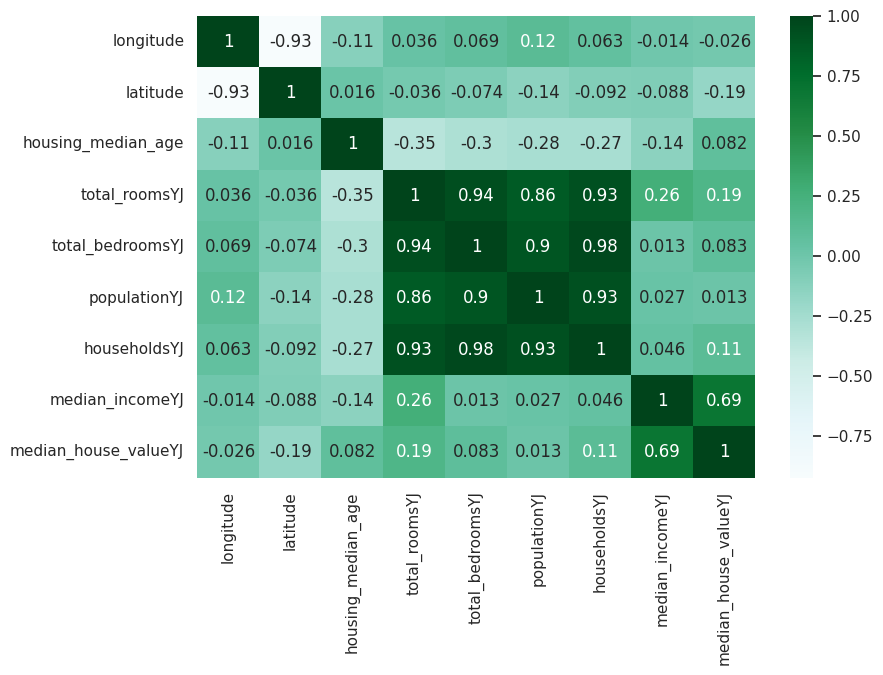

In [ ]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Supongamos que obtenemos la matriz de correlación de Pearson, pero a las variables
# indicadas con YJ se les aplica ajuste de sesgo con Yeo-Johnson:
variables = ['longitude', 'latitude', 'housing_median_age', 'total_roomsYJ',
             'total_bedroomsYJ', 'populationYJ', 'householdsYJ', 'median_incomeYJ',
             'median_house_valueYJ']

# Creamos un nuevo DataFrame para almacenar las variables transformadas:
df_procesado = pd.DataFrame()

for var in variables:
    if var.endswith('YJ'):
        # Identificamos las variables del DataFrame origial a las cuales les aplicaremos Yeo-Johnson:
        col_origen = var if var in misdatos.columns else var[:-2]

        # Aplicamos la transformación Yeo-Johnson.
        # Usamos doble corchete ya que la función power_transform requiere un array 2D:
        df_procesado[var] = power_transform(misdatos[[col_origen]], method='yeo-johnson')
    else:
        # Las variables que no terminan en 'YJ' se copian directamente de los datos originales.
        df_procesado[var] = misdatos[var]

# Obtenemos la matriz de correlación de Pearson:
matriz_correlacion = df_procesado.corr(method='pearson')

sns.set(rc={'figure.figsize':(9,6)})
sns.heatmap(matriz_correlacion, annot=True, cmap='BuGn' )
plt.show()

**PREGUNTAS:**

*   **Pregunta 2.1.** ¿A qué tipo de variables (numéricas o categóricas) se aplica la matriz de correlación Pearson? ¿Y cuál es el objetivo de obtener dicha matriz?

*   **Pregunta 2.2.** Con respecto a la variable de salida, ¿qué variables de entrada están mayormente correlacionadas con ella? ¿Tiene sentido dentro del contexto y significado de las variables del problema?

*   **Pregunta 2.3.** En particular ¿cómo explicas el valor de correlación obtenido del factor "longitude" con respecto a la variable de salida transformada?

*   **Pregunta 2.4.** ¿Y cómo explicas el valor de correlación obtenido del factor "latitude" con respecto a la variable de salida transformada? ¿Tiene sentido con respecto al significado del problema?

*   **Pregunta 2.5.** Observa que con respecto a las variables de entrada y el concepto de multicolinealidad, varias de ellas tienen un alto valor de correlación de Pearson, ¿qué decisiones podemos tomar ahora con respecto a dichas variables?

### **Respuestas:**


++++++++ Inicia sección para agregar texto ++++++++++++++++++++++++


*   **Respuesta 2.1.** La matriz de Correlación de Pearson se aplica a Variables numéricas continuas que tengan una relación cuantitativa medible. Excluyendo a las variables Categóricas en general el objetivo principal es medir la fuerza y la dirección de la relación lineal existente entre cada par de variables numéricas del conjunto de datos.
Lo que se quiere lograr es Identificar relaciones lineales, detección de multicolinealidad es decir si dos variables independientes tienen una correlación extremadamente alta, seleccionar las características con mayor potencial predictivo, exploración de datos proporciona una vista rápida y resumida del comportamiento global de todo el conjunto de datos numérico a través de un mapa de calor.


*   **Respuesta 2.2.** La variable con mayor correlación a la variable de salida es median_income la cual representa una correlación positiva muy alta aproximadamente entre 0.68 y 0.69. esto hace mucho sentido ya que el poder adquisitivo de los residentes es el factor determinante más directo del precio de las viviendas. Las zonas donde las familias tienen ingresos más altos atraen construcciones de mayor valor, mejor infraestructura y precios por metro cuadrado sustancialmente más elevados.
Variables de dimensión de la zona (total_rooms, housing_median_age, households, total_bedrooms) muestran una correlación muy baja 0.10 y 0.15. Variables de densidad/población (population): muestra una correlación neutra o ligeramente negativa alrededor de -0.02 a -0.05 mientras que las Variables geográficas (latitude y longitude) muestran correlaciones negativas moderadas/débiles alrededor de -0.14 y -0.05.


*   **Respuesta 2.3.** El coeficiente de Pearson mide únicamente la fuerza de una relación lineal entre dos variables. En este caso el valor de 0.026 el cual indica una relación prácticamente nula, pero evaluarla de manera aislada no hace ningún sentido ya que el valor de una propiedad se da por la zona en la que está para que un modelo de regresión lineal pueda aprovechar la información de longitude, es necesario combinarla con latitude que es básicamente lo que determina en su conjunto la zona donde está situada la casa. Se puede hacer mediante una técnica de Clustering para tener una distancia de centros urbanos y eso se determina una relación de valor de propiedad.


*   **Respuesta 2.4.** El coeficiente de correlación de Pearson entre la latitud y la variable de salida registra un valor de $-0.19$. Al comparar este resultado con el de la longitud (cuyo valor es prácticamente nulo), es evidente que existe una mayor correlación con la latitud, Mismo caso que la latitud para hacer un análisis mucho más exacto del valor de la casa se tiene que hacer un proceso de Clustering para determinar zonas de mayor valor.
Ejemplos claros zonas pegadas a las grandes ciudades como los Ángeles o San Francisco tienen mucho más valor que otras zonas aisladas medidas solo por la Latitud.


*   **Respuesta 2.5.** Cabe destacar que variables como total_rooms, total_bedrooms, population y households presentan una alta correlación entre sí, con valores que oscilan entre 0.86 y 0.98. Más que una ventaja, esto evidencia un problema claro de multicolinealidad entre las características de entrada. Por ello, para el desarrollo del modelo de regresión lineal, resulta conveniente seleccionar solo algunas de estas variables, combinarlas mediante ingeniería de características o aplicar técnicas de reducción de dimensionalidad


++++++++ Termina sección para agregar texto ++++++++++++++++++++++++

# **Ejercicio - 3: Conclusiones Finales**

**En particular, cuando hayas usado algún LLM, comenta qué tanto cambiaste a personalizaste las respuestas. Por ejemplo: ¿usaste todo el texto que te proporcionó o solo algunas partes?; ¿complementaste con varios LLM para cada respuesta? ¿Le hiciste preguntas adicionales, después de la primera?**



++++++++ Incluye a continuación tus conclusiones finales de la actividad ++++++++++++++++++++++++++

Este ejercicio me pareció muy interesante y me ayudo a pensar en los conceptos aprendidos en ciencia de datos de nuevo. Aquí aparecen conceptos interesantes donde empiezas a pensar en diversos caminos para que haga sentido una solución propuesta.
En cuanto a los LLM se me hacen herramientas muy útiles que reducen tu trabajo sin embargo no puedes poner la primer respuesta que te dan ya que necesita ser analizada por el autor y revisar si es correcta la respuesta y si es la respuesta a la pregunta que estás haciendo.


Google. (2026). Gemini (Versión de febrero de 2026) [Modelo de lenguaje de gran escala]. https://gemini.google.com utilizado para redacción y ortografía también fue consultado para validar información y generar ideas para respuesta.

None


++++++++ Termina sección para agregar texto ++++++++++++++++++++++++

# **<< Fin de la Actividad de la Semana 2 - California Housing>>**